## KNN Classification on Breast Cancer Dataset

This notebook will guide you through implementing the K-Nearest Neighbors (KNN) classification algorithm on the Breast Cancer dataset. We will cover essential machine learning concepts like train-test split, model training, and performance evaluation using various metrics.

In [1]:
# First, we need to import all the necessary libraries.
# `sklearn` (scikit-learn) is a powerful library for machine learning.
# `pandas` is good for handling data in tables.
# `numpy` is for numerical operations.

import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Loading the Breast Cancer Dataset

The Breast Cancer dataset is a classic dataset for binary classification. It contains features computed from digitized images of fine needle aspirate (FNA) of a breast mass. The goal is to classify whether the mass is malignant (cancerous) or benign (non-cancerous).

In [2]:
# Load the dataset from scikit-learn.
# `load_breast_cancer()` returns a dictionary-like object.

cancer = load_breast_cancer()

# The data (features) are in `cancer.data`.
# The target (what we want to predict) is in `cancer.target`.
# The feature names (column headers) are in `cancer.feature_names`.
# The target names (labels) are in `cancer.target_names`.

X = cancer.data  # Features
y = cancer.target # Target variable (0 for malignant, 1 for benign)

print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)
print("Feature names:", cancer.feature_names[:5]) # Display first 5 feature names
print("Target names:", cancer.target_names) # 0: malignant, 1: benign

# Let's put the data into a pandas DataFrame for easier viewing
df = pd.DataFrame(X, columns=cancer.feature_names)
df['target'] = y

print("\nFirst 5 rows of the dataset:")
display(df.head())

Shape of features (X): (569, 30)
Shape of target (y): (569,)
Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']
Target names: ['malignant' 'benign']

First 5 rows of the dataset:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### 2. Splitting Data into Training and Testing Sets

Before training any model, it's crucial to split your data into two parts: a **training set** and a **testing set**.

*   The **training set** is used to teach the model how to make predictions.
*   The **testing set** is used to evaluate how well the model performs on unseen data. This helps us to check if the model is truly learning and not just memorizing the training data (overfitting).

We typically use a `train_test_split` function, common splits are 70/30 or 80/20 for training/testing.

In [3]:
# We'll split 80% of the data for training and 20% for testing.
# `random_state` ensures that our split is the same every time we run the code.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train (training features):", X_train.shape)
print("Shape of X_test (testing features):", X_test.shape)
print("Shape of y_train (training target):", y_train.shape)
print("Shape of y_test (testing target):", y_test.shape)

Shape of X_train (training features): (455, 30)
Shape of X_test (testing features): (114, 30)
Shape of y_train (training target): (455,)
Shape of y_test (testing target): (114,)


### 3. Heuristic K Selection for KNN

In KNN, 'K' is the number of nearest neighbors considered when making a prediction. Choosing a good 'K' is important.

A simple heuristic (rule of thumb) for choosing 'K' is to take the square root of the total number of samples in your training data. If the result is an even number, it's often good practice to pick an odd number to avoid ties in classification (e.g., if K=2, and one neighbor is class A and one is class B, it's a tie). Let's calculate a `K` value based on this heuristic.

In [4]:
# Calculate K using the square root of the number of training samples.
# We will ensure K is an odd number.

num_training_samples = X_train.shape[0]
heuristic_k = int(np.sqrt(num_training_samples))

# Ensure K is odd
if heuristic_k % 2 == 0:
    heuristic_k -= 1 # Subtract 1 to make it odd
    if heuristic_k == 0: # Handle case where original is 1, becomes 0
        heuristic_k = 1

print(f"Number of training samples: {num_training_samples}")
print(f"Heuristic K value (approx. sqrt): {heuristic_k}")

# For simplicity, we will use this heuristic_k for our first model.

Number of training samples: 455
Heuristic K value (approx. sqrt): 21


### 4. Training the KNN Classifier

Now we will initialize our KNN classifier with the chosen `K` value and train it using our training data.

*   `n_neighbors` is the K value.
*   `fit(X_train, y_train)` is where the model 'learns' by storing the training data.

In [5]:
# Initialize the KNN classifier with our heuristic K.
knn_model = KNeighborsClassifier(n_neighbors=heuristic_k)

# Train the model using the training data.
knn_model.fit(X_train, y_train)

print(f"KNN model trained with K = {heuristic_k} neighbors.")

KNN model trained with K = 21 neighbors.


### 5. Making Predictions

After training, we use the model to make predictions on the unseen test data. This `y_pred` will be compared against the actual `y_test` to evaluate performance.

In [6]:
# Use the trained model to predict the classes for the test set.
y_pred = knn_model.predict(X_test)

# If you also need prediction probabilities (for ROC-AUC), use `predict_proba`.
y_pred_proba = knn_model.predict_proba(X_test)[:, 1] # Probability of the positive class (class 1 - benign)

print("First 10 actual labels (y_test):", y_test[:10])
print("First 10 predicted labels (y_pred):", y_pred[:10])

First 10 actual labels (y_test): [1 0 0 1 1 0 0 0 1 1]
First 10 predicted labels (y_pred): [1 0 0 1 1 0 0 0 1 1]


### 6. Evaluating Model Performance: Classification Metrics

For classification tasks, we use specific metrics to understand how well our model is performing. Unlike regression metrics (like Mean Squared Error), classification metrics focus on how many predictions were correct or incorrect, and what kind of errors were made.

*   **Accuracy**: The proportion of total correct predictions (both positive and negative) out of all predictions.
*   **Precision**: Out of all predicted positive cases, how many were actually positive? (Minimizes false positives).
*   **Recall (Sensitivity)**: Out of all actual positive cases, how many did the model correctly identify? (Minimizes false negatives).
*   **F1-Score**: The harmonic mean of Precision and Recall. It's a good measure when you need to balance both precision and recall, especially with imbalanced classes.

In [7]:
# Calculate various classification metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

Accuracy:  0.9649
Precision: 0.9467
Recall:    1.0000
F1-Score:  0.9726


### 7. ROC-AUC (Receiver Operating Characteristic - Area Under the Curve)

ROC-AUC is another powerful metric, especially for binary classification. It tells us how well the model distinguishes between positive and negative classes across all possible classification thresholds.

*   The **ROC curve** plots the True Positive Rate (Recall) against the False Positive Rate at various threshold settings.
*   The **AUC (Area Under the Curve)** measures the entire area underneath the ROC curve. An AUC of 1.0 means a perfect classifier, while an AUC of 0.5 means a classifier that performs no better than random guessing.

ROC-AUC Score: 0.9961


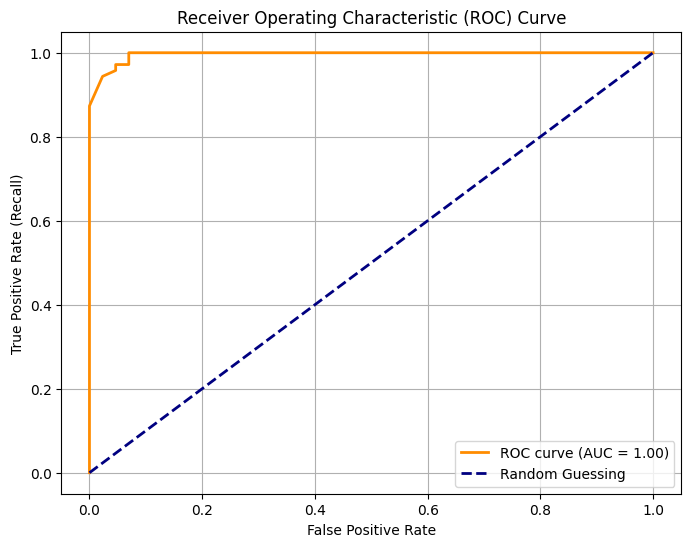

In [8]:
# Calculate the ROC-AUC score
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"ROC-AUC Score: {roc_auc:.4f}")

# Plot the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### 8. Cross-Validation

**Cross-validation** is a technique to get a more reliable estimate of model performance. Instead of a single train-test split, it divides the dataset into multiple 'folds' (e.g., 5 or 10).

Here's how K-fold cross-validation works:
1.  The dataset is split into K equal-sized folds.
2.  For each fold:
    *   One fold is used as the **test set**.
    *   The remaining K-1 folds are used as the **training set**.
3.  The model is trained and evaluated K times, each time with a different test fold.
4.  The results (e.g., accuracy scores) from each fold are averaged to get a more robust performance estimate.

This helps to reduce the impact of a particular data split and gives a better idea of how the model generalizes.

In [9]:
# We will use 5-fold cross-validation.
# This means the data will be split into 5 parts, and the model will be trained and tested 5 times.

cv_scores = cross_val_score(knn_model, X, y, cv=5) # 'cv' specifies the number of folds

print("Cross-validation scores (accuracy for each fold):")
print(cv_scores)
print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f}")
print(f"Standard Deviation of CV Accuracy: {np.std(cv_scores):.4f}")

Cross-validation scores (accuracy for each fold):
[0.86842105 0.92105263 0.93859649 0.95614035 0.96460177]
Mean CV Accuracy: 0.9298
Standard Deviation of CV Accuracy: 0.0341


### Comparison: Classification Metrics vs. Regression Metrics

This lab focused on **classification metrics** (Accuracy, Precision, Recall, F1-Score, ROC-AUC) which are used when you are predicting categories or labels (e.g., 'malignant' or 'benign'). These metrics tell us how many items were correctly assigned to their respective classes.

In contrast, **regression metrics** (like Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), R-squared) are used when you are predicting continuous numerical values (e.g., house prices, temperature). These metrics measure the difference between the predicted numerical value and the actual numerical value.

**Key Difference:**
*   **Classification**: Deals with discrete output (categories). Metrics measure correctness of class assignment.
*   **Regression**: Deals with continuous output (numbers). Metrics measure the error in numerical prediction.